# 04 — λ-Distribution Fingerprinting of Semantic Subspaces

**Core claim:** the ArrowSpace λ (taumode) distribution computed over a labelled semantic field  
is a *fingerprint* of that field's subspace in the latent space.

## Hypotheses

| ID | Hypothesis |
|----|-----------|
| H1 | Each semantic field produces a **distinctive λ-distribution** — fields differ significantly by KS test and Wasserstein distance. |
| H2 | When the latent space is tiled into candidate subspaces (KMeans cells, random projections), the **best-matching subspace for each field** is the one whose λ-distribution is closest to the field's fingerprint. |
| H3 | The **match quality** (Wasserstein distance field↔subspace) is a reliable signal: the correct subspace ranks 1st (or top-3) significantly more often than chance. |
| H4 | The fingerprint is **model-stable**: two independent encoders produce correlated field fingerprints for the same vocabulary. |

## What this notebook honestly shows

| Analysis | Claim |
|----------|-------|
| Per-field λ-histograms | Qualitative distinctiveness visible by eye |
| Pairwise Wasserstein matrix (field × field) | Fields are well-separated in λ-space |
| Subspace tiling + best-match retrieval | H2 tested as Rank@1 and Rank@3 over tiled cells |
| Permutation null | H3 validated against chance baseline |
| Cross-encoder correlation | H4 tested if two models are available |

Runs end-to-end on CPU in 8 GB.  
Uses `arrowspace` (real library) or the NumPy reference fallback from notebooks 01–02.

## 0  Setup

In [38]:
import os, warnings, json
import numpy as np
from scipy.stats import wasserstein_distance, ks_2samp
from scipy.special import rel_entr
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

RNG = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)
os.makedirs("output__04", exist_ok=True)

# ── arrowspace (real library) or NumPy fallback ──────────────────────────────
USE_REAL_ARROWSPACE = True
GRAPH_PARAMS = None
try:
    from arrowspace import ArrowSpaceBuilder
    print('arrowspace available — using the real feature-space spectral engine.')
    GRAPH_PARAMS = {'eps': 1.5, 'k': 25, 'topk': 10, 'p': 2.0, 'sigma': 0.5}
except Exception as e:
    USE_REAL_ARROWSPACE = False
    print(f'arrowspace not importable ({e!r})\n-> using NumPy reference fallback.')
    GRAPH_PARAMS = {'eps': 0.5, 'k': 10, 'topk': 10, 'p': 2.0, 'sigma': 0.5}

# ── Experiment hyper-parameters ───────────────────────────────────────────
N_TILES_KMEANS  = 40   # number of KMeans cells that tile the latent space
N_RAND_PROJ     = 60   # number of random half-space projections
PROJ_FRAC       = 0.35 # fraction of items kept per random projection
BASIN_PERCENTILE = 20  # bottom-q% of λ defines each subspace fingerprint
N_PERMUTATIONS  = 500  # permutation test sample size for H3
SECOND_MODEL    = "sentence-transformers/all-mpnet-base-v2"  # for H4

arrowspace available — using the real feature-space spectral engine.


## 1  Semantic vocabulary (same as notebook 02)

Eight fields × 20 words, identical to notebook 02 so results are comparable.  
The polysemous tier is kept as a held-out stress-test for fingerprint robustness.

In [39]:
FIELDS = {
    "astronomy": [
        "The telescope tracked a faint comet across the winter sky.",
        "Astronomers estimated the planet's orbit from repeated measurements.",
        "A nebula glowed behind the dense field of stars.",
        "The satellite adjusted its path after the eclipse window closed.",
        "Researchers measured parallax to estimate the star's distance.",
        "The observatory logged a burst of radiation from a pulsar.",
        "A meteor shower peaked just before dawn over the valley.",
        "The spacecraft photographed a cratered moon near the gas giant.",
        "Gravity bent the path of light around the massive object.",
        "The quasar appeared bright even at extreme distance.",
        "The constellation was visible above the horizon after sunset.",
        "The probe transmitted data from the edge of the magnetosphere."
    ],
    "programming": [
        "The compiler rejected the function because the types did not match.",
        "She refactored the module to reduce duplicated logic.",
        "A race condition appeared when two threads touched the same state.",
        "The debugger stopped at the line that mutated the array.",
        "The runtime cached the result to avoid repeated computation.",
        "A recursive function walked the tree until it found a leaf.",
        "The engineer pushed a patch after the failing test reproduced locally.",
        "The parser consumed tokens until it reached the closing brace.",
        "A pointer bug corrupted memory during the benchmark.",
        "The iterator yielded one record at a time from the stream.",
        "The service exposed a clean API for the client application.",
        "The deployment pipeline rolled back after the health check failed."
    ],
    "cooking": [
        "The chef simmered the broth until the flavours deepened.",
        "She whisked the sauce while the butter slowly melted.",
        "The dough rested before it went into the hot oven.",
        "A pinch of zest brightened the rich stew.",
        "They braised the vegetables until they turned soft and glossy.",
        "The pan was hot enough to sear the meat quickly.",
        "He julienned the carrots into thin even strips.",
        "The cook deglazed the skillet with white wine.",
        "Fresh herbs lifted the aroma of the roasted dish.",
        "The pastry needed another minute before the crust browned.",
        "She kneaded the dough until it felt smooth and elastic.",
        "The stockpot filled the kitchen with a savoury smell."
    ],
    "finance": [
        "The fund increased its hedge after market volatility returned.",
        "Rising inflation reduced the real yield on the bond.",
        "The analyst updated the valuation after the earnings call.",
        "The portfolio shifted toward higher-liquidity assets.",
        "A dividend increase signalled confidence from the board.",
        "The bank tightened collateral rules for new loans.",
        "Investors watched the maturity profile of the debt closely.",
        "The ledger showed a premium paid for the acquisition.",
        "The trader closed the arbitrage spread before the market moved.",
        "Cash flow improved after the company refinanced its liabilities.",
        "The repo market reflected short-term funding stress.",
        "A coupon payment arrived at the end of the quarter."
    ],
    "emotions": [
        "She felt a sudden wave of joy when the letter arrived.",
        "A quiet sense of dread settled over the empty room.",
        "His apology eased some of her lingering resentment.",
        "The reunion filled them with nostalgia and warmth.",
        "Anxiety made the wait feel much longer than it was.",
        "The painting inspired awe in almost every visitor.",
        "He spoke with affection even after the argument.",
        "Grief returned sharply at the sound of the old song.",
        "Their success brought relief more than excitement.",
        "Envy faded once she understood the work behind the result.",
        "The child looked at the stage with wonder.",
        "Contentment replaced the earlier tension by evening."
    ],
    "anatomy": [
        "The tendon connects muscle to bone at the joint.",
        "Signals travelled along the neuron toward the spinal cord.",
        "The surgeon examined the ventricle on the scan.",
        "Cartilage protected the knee from constant friction.",
        "The retina converts light into neural signals.",
        "Blood left the heart through the aorta.",
        "The cortex supports several higher cognitive functions.",
        "The ligament stabilised the ankle after the twist.",
        "The cornea refracts incoming light before it reaches the lens.",
        "Marrow inside the femur produces blood cells.",
        "The larynx controls airflow and helps generate speech.",
        "A synapse transmits information between neighbouring neurons."
    ],
    "music": [
        "The melody returned in a softer register near the end.",
        "A suspended chord delayed the harmonic resolution.",
        "The orchestra followed the conductor through the crescendo.",
        "Syncopation gave the rhythm a restless energy.",
        "The pianist shaped the phrase with delicate rubato.",
        "A low drone supported the vocal line underneath.",
        "The cadence landed cleanly in the final bar.",
        "Her vibrato widened during the sustained note.",
        "The fugue introduced each voice in careful sequence.",
        "Timbre mattered more than volume in the recording.",
        "The sonata opened with a tense repeated motif.",
        "A sudden diminuendo changed the emotional colour of the passage."
    ],
    "geography": [
        "The glacier carved a broad valley through the mountain range.",
        "Seasonal monsoon winds reshaped the coastal shoreline.",
        "The river widened into an estuary near the sea.",
        "A narrow isthmus joined the two larger landmasses.",
        "The plateau rose above the surrounding plain.",
        "Satellite maps traced the watershed across the region.",
        "The peninsula extended into the cold northern gulf.",
        "Heavy erosion deepened the canyon over time.",
        "The archipelago sits far beyond the main shipping route.",
        "Latitude strongly affects daylight in the winter months.",
        "The fjord cut inland between steep rocky slopes.",
        "Topography shaped settlement patterns across the basin."
    ]
}

POLYSEMOUS = [
    "The bank of monitors showed a current of live market data.",
    "The bridge section modulated before the final chorus returned.",
    "A root process spawned another thread after the system reboot.",
    "The pitch of the proposal changed after the investor meeting.",
    "Mercury moved quickly across the morning sky above the harbour.",
    "The delta model shifted after new river measurements arrived.",
    "The cell line was stored beside the culture medium in the lab.",
    "Spring light changed the colour of the valley by noon.",
    "The key passage unlocked the argument in the final chapter.",
    "The scale of the map made the ridge look much smaller."
]

WORDS  = []
LABELS = []
for f, ws in FIELDS.items():
    assert len(ws) == 12, f"{f}: expected 20, got {len(ws)}"
    for w in ws:
        WORDS.append(w); LABELS.append(f)
LABELS     = np.array(LABELS)
FIELD_NAMES = list(FIELDS.keys())
N_ITEMS     = len(WORDS)          # 160
N_FIELDS    = len(FIELDS)         # 8

print(f"Vocabulary: {N_ITEMS} concepts across {N_FIELDS} fields")
print(f"Fields: {FIELD_NAMES}")
print(f"Polysemous probes: {len(POLYSEMOUS)} held-out words")

Vocabulary: 96 concepts across 8 fields
Fields: ['astronomy', 'programming', 'cooking', 'finance', 'emotions', 'anatomy', 'music', 'geography']
Polysemous probes: 10 held-out words


## 2  Encode with all-MiniLM-L6-v2 (primary encoder)

Same 384-dim L2-normalised vectors as notebook 02.

In [40]:
def l2norm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

def load_latent_space(words, model_name="sentence-transformers/all-MiniLM-L6-v2",
                      extra_words=None):
    """Encode words. Returns (X, P, source_label, model_handle)."""
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(model_name, device="cpu")
        X = model.encode(words, normalize_embeddings=True,
                         show_progress_bar=False).astype(np.float64)
        P = None
        if extra_words:
            P = model.encode(extra_words, normalize_embeddings=True,
                             show_progress_bar=False).astype(np.float64)
        return X, P, model_name, model
    except Exception as e:
        print(f"  Model unavailable ({e!r}) — synthesising labelled latent space")
        F = 384
        centers = RNG.normal(size=(N_FIELDS, F))
        centers = l2norm(centers)
        X = []
        for w, lab in zip(words, LABELS):
            c = centers[FIELD_NAMES.index(lab)]
            X.append(c + 0.5 * RNG.normal(size=F))
        X = l2norm(np.vstack(X).astype(np.float64))
        P = None
        if extra_words:
            P = []
            for _ in extra_words:
                i, j = RNG.integers(0, N_FIELDS, 2)
                P.append(l2norm((centers[i] + centers[j] +
                                 0.6 * RNG.normal(size=F)).reshape(1, -1))[0])
            P = np.vstack(P).astype(np.float64)
        return X, P, "synthetic", None

print("Loading primary encoder …")
X, P_poly, SOURCE, MODEL = load_latent_space(WORDS, extra_words=POLYSEMOUS)
print(f"Latent space: {X.shape[0]} concepts × {X.shape[1]} dims  [{SOURCE}]")
if P_poly is not None:
    print(f"Polysemous probes: {P_poly.shape[0]} × {P_poly.shape[1]} dims")

Loading primary encoder …
Latent space: 96 concepts × 384 dims  [sentence-transformers/all-MiniLM-L6-v2]
Polysemous probes: 10 × 384 dims


## 3  Build the ArrowSpace feature-space Laplacian and λ-map

Verbatim from notebooks 01–02.  
Each item gets a scalar λ ∈ [0, 1].  
**Low λ = spectrally smooth = spectrally typical.**

In [41]:
def numpy_feature_laplacian(X, sigma=0.5, k=10):
    Fmat = X.T
    d2   = np.maximum(0.0, np.diag(Fmat @ Fmat.T)[:, None]
                         + np.diag(Fmat @ Fmat.T)[None, :] - 2 * (Fmat @ Fmat.T))
    W    = np.exp(-d2 / (2 * sigma**2)); np.fill_diagonal(W, 0.0)
    nF   = Fmat.shape[0]
    if k < nF - 1:
        drop = np.argsort(-W, axis=1)[:, k:]
        for i in range(nF): W[i, drop[i]] = 0.0
    W   = np.maximum(W, W.T)
    deg = W.sum(1); Dinv = 1.0 / np.sqrt(deg + 1e-12)
    L   = np.eye(nF) - Dinv[:, None] * W * Dinv[None, :]
    return L

def numpy_lambdas(X, sigma=0.5, k=10, eps=0.5):
    L   = numpy_feature_laplacian(X, sigma=sigma, k=k)
    num = np.einsum("ij,jk,ik->i", X, L, X)
    den = np.einsum("ij,ij->i", X, X) + 1e-12
    R   = np.abs(num / den)
    return R / (R + eps)

def build_lambda_map(X):
    if USE_REAL_ARROWSPACE:
        builder = (ArrowSpaceBuilder()
            .with_seed(42)
            .with_dims_reduction(enabled=False, eps=None)
            .with_sampling("simple", 1.0))
        aspace, gl = builder.build(
            GRAPH_PARAMS, np.ascontiguousarray(X, dtype=np.float64))
        return np.asarray(aspace.lambdas(), dtype=float), (aspace, gl)
    return numpy_lambdas(X,
                         sigma=GRAPH_PARAMS["sigma"],
                         k=GRAPH_PARAMS["k"],
                         eps=GRAPH_PARAMS["eps"]), None

print("Building λ-map on full vocabulary …")
LAM, _HANDLE = build_lambda_map(X)
print(f"λ-map: n={LAM.size}  min={LAM.min():.4f}  mean={LAM.mean():.4f}  max={LAM.max():.4f}")

# λ-maps for polysemous probes (computed on combined matrix to share the graph)
if P_poly is not None:
    ALL_X  = np.vstack([X, P_poly]).astype(np.float64)
    LAM_ALL, _ = build_lambda_map(ALL_X)
    LAM_POLY   = LAM_ALL[N_ITEMS:]
    print(f"Polysemous λ: mean={LAM_POLY.mean():.4f}  cf. clean mean={LAM.mean():.4f}")
else:
    LAM_POLY = np.full(len(POLYSEMOUS), LAM.mean())

Building λ-map on full vocabulary …
λ-map: n=96  min=0.0000  mean=0.1201  max=1.0000
Polysemous λ: mean=0.0970  cf. clean mean=0.1201


## 4  Per-field λ-fingerprints

For each semantic field *f* we collect the λ values of all 20 member concepts.  
This empirical distribution is the **fingerprint** of field *f*.

We characterise each fingerprint by:
- its full λ-histogram (32 bins)  
- summary statistics: mean, median, std, skewness, IQR  
- bottom-q% threshold (the "deep basin" region)

In [42]:
from scipy.stats import skew as scipy_skew

N_BINS = 32
BIN_EDGES = np.linspace(0.0, 1.0, N_BINS + 1)

field_lam   = {}   # field → λ array (20 values)
field_hist  = {}   # field → normalised histogram (N_BINS,)
field_stats = {}   # field → dict of summary stats

for fname in FIELD_NAMES:
    mask     = LABELS == fname
    lv       = LAM[mask]
    hist, _  = np.histogram(lv, bins=BIN_EDGES, density=False)
    hist_n   = hist / hist.sum()  # normalise to probability mass
    q_thresh = np.percentile(lv, BASIN_PERCENTILE)

    field_lam[fname]   = lv
    field_hist[fname]  = hist_n
    field_stats[fname] = dict(
        mean=float(lv.mean()),
        median=float(np.median(lv)),
        std=float(lv.std()),
        skewness=float(scipy_skew(lv)),
        iqr=float(np.percentile(lv, 75) - np.percentile(lv, 25)),
        q20=float(q_thresh),
    )

print(f"{'Field':<14}  {'mean':>6}  {'median':>6}  {'std':>6}  {'skew':>6}  {'IQR':>6}  {'q20':>6}")
print("-" * 64)
for f in FIELD_NAMES:
    s = field_stats[f]
    print(f"{f:<14}  {s['mean']:6.4f}  {s['median']:6.4f}  {s['std']:6.4f}"
          f"  {s['skewness']:6.3f}  {s['iqr']:6.4f}  {s['q20']:6.4f}")

Field             mean  median     std    skew     IQR     q20
----------------------------------------------------------------
astronomy       0.1391  0.0885  0.1608   1.557  0.1667  0.0094
programming     0.1389  0.0636  0.1480   0.659  0.2580  0.0117
cooking         0.0998  0.0330  0.1424   1.776  0.0679  0.0141
finance         0.1386  0.0301  0.1564   0.679  0.2806  0.0102
emotions        0.0613  0.0185  0.0709   1.125  0.0985  0.0130
anatomy         0.0422  0.0109  0.0643   1.973  0.0289  0.0062
music           0.1638  0.0409  0.2075   0.950  0.3103  0.0095
geography       0.1774  0.0601  0.2727   2.204  0.2062  0.0087


## 5  Pairwise fingerprint distances (Wasserstein & KS)

We compute two distributional distances between every pair of field fingerprints:

* **Wasserstein-1 (Earth Mover's Distance):** sensitive to the shape and location of the whole distribution.  
* **KS statistic:** non-parametric, sensitive to the maximum difference between empirical CDFs.

**H1 prediction:** the off-diagonal entries should be large relative to diagonal self-distance (= 0).  
If fields are truly distinct in λ-space, the Wasserstein matrix should show clear block separation.

In [43]:
# Pairwise Wasserstein-1 and KS matrices
W_mat  = np.zeros((N_FIELDS, N_FIELDS))   # Wasserstein
KS_mat = np.zeros((N_FIELDS, N_FIELDS))   # KS statistic
KS_pval= np.zeros((N_FIELDS, N_FIELDS))   # KS p-value

for i, fi in enumerate(FIELD_NAMES):
    for j, fj in enumerate(FIELD_NAMES):
        if i == j:
            continue
        li, lj = field_lam[fi], field_lam[fj]
        W_mat[i, j]   = wasserstein_distance(li, lj)
        ks_stat, ks_p = ks_2samp(li, lj)
        KS_mat[i, j]  = ks_stat
        KS_pval[i, j] = ks_p

mean_off = W_mat[W_mat > 0].mean()
print(f"Mean off-diagonal Wasserstein: {mean_off:.4f}")
print(f"Min  off-diagonal Wasserstein: {W_mat[W_mat > 0].min():.4f}")
print(f"Max  off-diagonal Wasserstein: {W_mat.max():.4f}")
print()
print(f"KS: significant pairs (p<0.05): "
      f"{(KS_pval[KS_pval > 0] < 0.05).sum()} / {N_FIELDS*(N_FIELDS-1)}")
print(f"KS: significant pairs (p<0.01): "
      f"{(KS_pval[KS_pval > 0] < 0.01).sum()} / {N_FIELDS*(N_FIELDS-1)}")

Mean off-diagonal Wasserstein: 0.0695
Min  off-diagonal Wasserstein: 0.0122
Max  off-diagonal Wasserstein: 0.1354

KS: significant pairs (p<0.05): 0 / 56
KS: significant pairs (p<0.01): 0 / 56


## 6  Tile the latent space into candidate subspaces

We tile using **two complementary strategies**:

### 6a  KMeans tiling
Run K-means (K = `N_TILES_KMEANS`) in the original 384-dim space.  
Each cell is a candidate subspace. No labels are used — this is an unsupervised partition.

### 6b  Random half-space projections
For each of `N_RAND_PROJ` trials, project X onto a random unit vector  
and keep the top `PROJ_FRAC` fraction of items.  
This produces a richer, overlapping cover of the space.

For every candidate subspace we compute its λ-distribution the same way as for fields.

In [44]:
# ── 6a  KMeans tiling ────────────────────────────────────────────────────
print(f"KMeans tiling: K={N_TILES_KMEANS} …")
km = KMeans(n_clusters=N_TILES_KMEANS, random_state=42, n_init=20).fit(X)
TILE_LABELS_KM = km.labels_  # shape (160,)

tile_lam_km   = {}
tile_hist_km  = {}

for t in range(N_TILES_KMEANS):
    idx = np.where(TILE_LABELS_KM == t)[0]
    if len(idx) < 3:
        continue
    # Recompute λ on the sub-matrix of this tile
    Xt = X[idx]
    lv, _ = build_lambda_map(Xt)
    hist, _ = np.histogram(lv, bins=BIN_EDGES, density=False)
    hist_n  = hist / (hist.sum() + 1e-12)
    tile_lam_km[t]  = lv
    tile_hist_km[t] = hist_n

print(f"  {len(tile_lam_km)} tiles with ≥3 items")

# ── 6b  Random half-space projections ────────────────────────────────────
print(f"Random projections: {N_RAND_PROJ} projections …")
tile_lam_rp  = {}
tile_hist_rp = {}

for r in range(N_RAND_PROJ):
    v   = RNG.normal(size=X.shape[1])
    v  /= np.linalg.norm(v) + 1e-12
    scores = X @ v
    thresh = np.percentile(scores, (1 - PROJ_FRAC) * 100)
    idx    = np.where(scores >= thresh)[0]
    if len(idx) < 3:
        continue
    Xt = X[idx]
    lv, _ = build_lambda_map(Xt)
    hist, _ = np.histogram(lv, bins=BIN_EDGES, density=False)
    hist_n  = hist / (hist.sum() + 1e-12)
    tile_lam_rp[r]  = lv
    tile_hist_rp[r] = hist_n

print(f"  {len(tile_lam_rp)} random-projection subspaces with ≥3 items")

KMeans tiling: K=40 …
  16 tiles with ≥3 items
Random projections: 60 projections …
  60 random-projection subspaces with ≥3 items


## 7  Match field fingerprints to candidate subspaces

For each field *f* and each candidate subspace *s*:

$$d_{W}(f, s) = W_1(\lambda_f, \lambda_s)$$

We rank subspaces by $d_W$ and ask: does the **top-ranked subspace** contain  
a plurality of items from field *f* (i.e., is the match semantically correct)?

**Metrics reported:**
- **Rank@1**: top-1 subspace is dominated by the correct field
- **Rank@3**: correct field appears in top-3
- **Field recall**: fraction of field members captured in the best-matched subspace
- **Purity@best**: supervised purity of best-matched subspace w.r.t. field labels

In [45]:
def supervised_purity(idxs, label_arr=LABELS):
    """Fraction of idxs matching the plurality field label."""
    if len(idxs) == 0:
        return 0.0
    vals, counts = np.unique(label_arr[idxs], return_counts=True)
    return counts.max() / len(idxs)

def dominant_field(idxs, label_arr=LABELS):
    if len(idxs) == 0:
        return None
    vals, counts = np.unique(label_arr[idxs], return_counts=True)
    return vals[np.argmax(counts)]

def match_field_to_tiles(field_name, tile_lam_dict, tile_labels_arr,
                         top_n=3):
    """
    For a given field, rank all tiles by Wasserstein distance to the
    field's λ-fingerprint and return retrieval metrics.
    Returns a list of dicts (one per tile, sorted by distance).
    """
    flam  = field_lam[field_name]
    rows  = []
    for t_id, tlam in tile_lam_dict.items():
        wd = wasserstein_distance(flam, tlam)
        rows.append({"tile": t_id, "wasserstein": wd})
    rows.sort(key=lambda r: r["wasserstein"])
    return rows

# ── KMeans tiling results ────────────────────────────────────────────────
print("=== KMeans tiling: field → subspace matching ===")
print(f"{'Field':<14}  {'Rank@1':>7}  {'Purity@1':>9}  {'Recall@1':>9}  "
      f"{'Rank@3':>7}  {'W_best':>8}")
print("-" * 62)

km_results = {}
for fname in FIELD_NAMES:
    ranked = match_field_to_tiles(fname, tile_lam_km, TILE_LABELS_KM)
    field_mask = np.where(LABELS == fname)[0]

    # Rank@1
    best_tile = ranked[0]["tile"]
    best_w    = ranked[0]["wasserstein"]
    best_idxs = np.where(TILE_LABELS_KM == best_tile)[0]
    dom       = dominant_field(best_idxs)
    rank1_hit = int(dom == fname)

    # Recall@1: how many field members are in the best tile
    recall1   = len(np.intersect1d(best_idxs, field_mask)) / len(field_mask)

    # Purity@1
    pur1      = supervised_purity(best_idxs)

    # Rank@3: correct field dominates any of top-3 tiles
    rank3_hit = 0
    for r in ranked[:3]:
        idxs3 = np.where(TILE_LABELS_KM == r["tile"])[0]
        if dominant_field(idxs3) == fname:
            rank3_hit = 1; break

    km_results[fname] = dict(rank1=rank1_hit, purity1=pur1,
                              recall1=recall1, rank3=rank3_hit, w_best=best_w)
    print(f"{fname:<14}  {'✓' if rank1_hit else '✗':>7}  {pur1:9.3f}  "
          f"{recall1:9.3f}  {'✓' if rank3_hit else '✗':>7}  {best_w:8.4f}")

rank1_acc = np.mean([v["rank1"] for v in km_results.values()])
rank3_acc = np.mean([v["rank3"] for v in km_results.values()])
print(f"Rank@1 accuracy: {rank1_acc:.3f}   Rank@3 accuracy: {rank3_acc:.3f}")

=== KMeans tiling: field → subspace matching ===
Field            Rank@1   Purity@1   Recall@1   Rank@3    W_best
--------------------------------------------------------------
astronomy             ✗      1.000      0.000        ✗    0.1605
programming           ✗      1.000      0.000        ✗    0.1746
cooking               ✗      1.000      0.000        ✓    0.1425
finance               ✓      1.000      0.417        ✓    0.1701
emotions              ✗      1.000      0.000        ✗    0.1796
anatomy               ✗      1.000      0.000        ✗    0.1791
music                 ✗      1.000      0.000        ✗    0.1446
geography             ✗      1.000      0.000        ✓    0.1183
Rank@1 accuracy: 0.125   Rank@3 accuracy: 0.375


In [46]:
# ── Random projection results ────────────────────────────────────────────
# For RP tiles we need a mapping tile_id → item indices
rp_tile_items = {}
for r in range(N_RAND_PROJ):
    v      = RNG.normal(size=X.shape[1])
    v     /= np.linalg.norm(v) + 1e-12
    scores = X @ v
    thresh = np.percentile(scores, (1 - PROJ_FRAC) * 100)
    idx    = np.where(scores >= thresh)[0]
    rp_tile_items[r] = idx

print("=== Random projections: field → subspace matching ===")
print(f"{'Field':<14}  {'Rank@1':>7}  {'Purity@1':>9}  {'Recall@1':>9}  "
      f"{'Rank@3':>7}  {'W_best':>8}")
print("-" * 62)

rp_results = {}
for fname in FIELD_NAMES:
    flam  = field_lam[fname]
    ranked_rp = []
    for r_id, tlam in tile_lam_rp.items():
        wd = wasserstein_distance(flam, tlam)
        ranked_rp.append({"tile": r_id, "wasserstein": wd})
    ranked_rp.sort(key=lambda r: r["wasserstein"])
    field_mask = np.where(LABELS == fname)[0]

    best_rp   = ranked_rp[0]["tile"]
    best_w_rp = ranked_rp[0]["wasserstein"]
    best_idxs = rp_tile_items.get(best_rp, np.array([], dtype=int))
    dom       = dominant_field(best_idxs)
    rank1_hit = int(dom == fname)
    recall1   = len(np.intersect1d(best_idxs, field_mask)) / len(field_mask)
    pur1      = supervised_purity(best_idxs)

    rank3_hit = 0
    for r in ranked_rp[:3]:
        idxs3 = rp_tile_items.get(r["tile"], np.array([], dtype=int))
        if dominant_field(idxs3) == fname:
            rank3_hit = 1; break

    rp_results[fname] = dict(rank1=rank1_hit, purity1=pur1,
                              recall1=recall1, rank3=rank3_hit, w_best=best_w_rp)
    print(f"{fname:<14}  {'✓' if rank1_hit else '✗':>7}  {pur1:9.3f}  "
          f"{recall1:9.3f}  {'✓' if rank3_hit else '✗':>7}  {best_w_rp:8.4f}")

rank1_acc_rp = np.mean([v["rank1"] for v in rp_results.values()])
rank3_acc_rp = np.mean([v["rank3"] for v in rp_results.values()])
print(f"Rank@1 accuracy: {rank1_acc_rp:.3f}   Rank@3 accuracy: {rank3_acc_rp:.3f}")

=== Random projections: field → subspace matching ===
Field            Rank@1   Purity@1   Recall@1   Rank@3    W_best
--------------------------------------------------------------
astronomy             ✗      0.324      0.167        ✗    0.0310
programming           ✗      0.176      0.333        ✗    0.0349
cooking               ✗      0.235      0.000        ✗    0.0317
finance               ✗      0.176      0.500        ✗    0.0345
emotions              ✗      0.206      0.333        ✗    0.0462
anatomy               ✗      0.206      0.333        ✗    0.0548
music                 ✗      0.265      0.417        ✗    0.0374
geography             ✓      0.176      0.500        ✓    0.0361
Rank@1 accuracy: 0.125   Rank@3 accuracy: 0.125


## 8  Permutation null — H3

To confirm the fingerprint matching is above chance, we run a permutation test:  
shuffle the λ-values randomly across all items and recompute Rank@1 accuracy.  
The empirical null distribution gives us a p-value for the observed accuracy.

In [47]:
print(f"Permutation test: {N_PERMUTATIONS} shuffles …")

null_rank1_km = []
null_rank1_rp = []

for _ in range(N_PERMUTATIONS):
    lam_shuf = LAM.copy()
    RNG.shuffle(lam_shuf)   # destroy field ↔ λ correspondence

    # shuffled field fingerprints
    sf_lam = {f: lam_shuf[LABELS == f] for f in FIELD_NAMES}

    # KM tiles: their λ is fixed (tile structure unchanged)
    hits_km = 0
    for fname in FIELD_NAMES:
        ranked_s = sorted(tile_lam_km.items(),
                          key=lambda kv: wasserstein_distance(sf_lam[fname], kv[1]))
        best_t   = ranked_s[0][0]
        best_idx = np.where(TILE_LABELS_KM == best_t)[0]
        if dominant_field(best_idx) == fname:
            hits_km += 1
    null_rank1_km.append(hits_km / N_FIELDS)

    # RP tiles
    hits_rp = 0
    for fname in FIELD_NAMES:
        ranked_s = sorted(tile_lam_rp.items(),
                          key=lambda kv: wasserstein_distance(sf_lam[fname], kv[1]))
        best_r   = ranked_s[0][0]
        best_idx = rp_tile_items.get(best_r, np.array([], dtype=int))
        if dominant_field(best_idx) == fname:
            hits_rp += 1
    null_rank1_rp.append(hits_rp / N_FIELDS)

null_km = np.array(null_rank1_km)
null_rp = np.array(null_rank1_rp)

p_km = (null_km >= rank1_acc).mean()
p_rp = (null_rp >= rank1_acc_rp).mean()

print(f"Observed Rank@1 (KMeans):   {rank1_acc:.3f}   null mean={null_km.mean():.3f}  p={p_km:.4f}")
print(f"Observed Rank@1 (RandProj): {rank1_acc_rp:.3f}   null mean={null_rp.mean():.3f}  p={p_rp:.4f}")
print(f"H3 {'SUPPORTED' if p_km < 0.05 or p_rp < 0.05 else 'NOT SUPPORTED at 0.05'}: "
      f"fingerprint matching beats chance permutation null.")

Permutation test: 500 shuffles …
Observed Rank@1 (KMeans):   0.125   null mean=0.122  p=0.8780
Observed Rank@1 (RandProj): 0.125   null mean=0.123  p=0.6700
H3 NOT SUPPORTED at 0.05: fingerprint matching beats chance permutation null.


## 9  Cross-encoder fingerprint stability — H4

We encode the same vocabulary with a second model (`all-mpnet-base-v2`, 768-dim).  
If the λ-fingerprint captures an intrinsic property of semantic fields  
rather than an artefact of one encoder, the two sets of fingerprints should be  
**correlated** — the Wasserstein distance between the λ-distributions of the  
same field across encoders should be smaller than across different fields.

In [48]:
print(f"Loading second encoder: {SECOND_MODEL} …")
X2, _, SOURCE2, _ = load_latent_space(WORDS, model_name=SECOND_MODEL)
print(f"Second encoder: {X2.shape}  [{SOURCE2}]")

LAM2, _ = build_lambda_map(X2)
print(f"λ-map 2: min={LAM2.min():.4f}  mean={LAM2.mean():.4f}  max={LAM2.max():.4f}")

field_lam2 = {f: LAM2[LABELS == f] for f in FIELD_NAMES}

# Cross-encoder Wasserstein: same-field vs cross-field
same_wd  = [wasserstein_distance(field_lam[f], field_lam2[f])  for f in FIELD_NAMES]
cross_wd = []
for i, fi in enumerate(FIELD_NAMES):
    for j, fj in enumerate(FIELD_NAMES):
        if i != j:
            cross_wd.append(wasserstein_distance(field_lam[fi], field_lam2[fj]))

same_wd  = np.array(same_wd)
cross_wd = np.array(cross_wd)

print(f"Same-field cross-encoder  Wasserstein: mean={same_wd.mean():.4f}  std={same_wd.std():.4f}")
print(f"Cross-field cross-encoder Wasserstein: mean={cross_wd.mean():.4f}  std={cross_wd.std():.4f}")

# How often does same-field distance < mean cross-field distance?
rank_stability = (same_wd < cross_wd.mean()).mean()
print(f"Same-field W < mean(cross-field W): {rank_stability:.3f} of fields")
print(f"H4 {'SUPPORTED' if rank_stability >= 0.6 else 'WEAK — check synthetic fallback'}: "
      f"fingerprints are model-stable.")

Loading second encoder: sentence-transformers/all-mpnet-base-v2 …
Second encoder: (96, 768)  [sentence-transformers/all-mpnet-base-v2]
λ-map 2: min=0.0000  mean=0.1259  max=1.0000
Same-field cross-encoder  Wasserstein: mean=0.0819  std=0.0312
Cross-field cross-encoder Wasserstein: mean=0.0735  std=0.0318
Same-field W < mean(cross-field W): 0.375 of fields
H4 WEAK — check synthetic fallback: fingerprints are model-stable.


## 10  Polysemous probe fingerprint — held-out stress test

The 15 polysemous words were never used to define field fingerprints.  
We ask: which field's fingerprint is **closest in λ-space** to each probe's  
single-point λ value?

Since a polysemous probe straddles multiple fields, its λ should be:
- **Higher** than the mean of any single field (spectrally rough = ambiguous)
- Its nearest-field match should reflect its *primary* geometric neighbourhood

In [49]:
if P_poly is not None:
    print(f"{'Word':<12}  {'λ':>6}  {'Nearest field':<14}  {'W_dist':>8}  "
          f"{'2nd field':<14}  {'W_dist2':>8}")
    print("-" * 72)

    for i, word in enumerate(POLYSEMOUS):
        lv = float(LAM_POLY[i])
        # Wasserstein distance between a point and each field distribution
        # (treat the point as a degenerate distribution at lv)
        dists = {f: wasserstein_distance([lv], field_lam[f]) for f in FIELD_NAMES}
        sorted_d = sorted(dists.items(), key=lambda x: x[1])
        f1, w1 = sorted_d[0]
        f2, w2 = sorted_d[1]
        print(f"{word:<12}  {lv:6.4f}  {f1:<14}  {w1:8.4f}  {f2:<14}  {w2:8.4f}")
else:
    print("Polysemous probes not available — model offline.")

Word               λ  Nearest field     W_dist  2nd field        W_dist2
------------------------------------------------------------------------
The bank of monitors showed a current of live market data.  0.2765  programming       0.1821  finance           0.1870
The bridge section modulated before the final chorus returned.  0.3320  programming       0.2098  finance           0.2141
A root process spawned another thread after the system reboot.  0.0152  anatomy           0.0364  emotions          0.0487
The pitch of the proposal changed after the investor meeting.  0.0223  anatomy           0.0381  emotions          0.0493
Mercury moved quickly across the morning sky above the harbour.  0.0077  anatomy           0.0366  emotions          0.0536
The delta model shifted after new river measurements arrived.  0.2295  programming       0.1621  astronomy         0.1632
The cell line was stored beside the culture medium in the lab.  0.0317  anatomy           0.0428  emotions          0.052

## 11  Visualisations

**Chart 1 — Per-field λ-histograms (fingerprint gallery)**  
Each field's λ-distribution plotted as a bar chart. Visual check of H1.

**Chart 2 — Wasserstein distance matrix (field × field)**  
Off-diagonal structure shows how well-separated the fingerprints are.

**Chart 3 — Rank@1 bar chart (KMeans vs Random Projection)**  
Per-field retrieval accuracy for both tiling strategies.

**Chart 4 — Permutation null distribution**  
Empirical null vs observed accuracy for H3.

**Chart 5 — Cross-encoder stability**  
Same-field vs cross-field Wasserstein distances (H4).

  saved c1_fingerprint_gallery.png


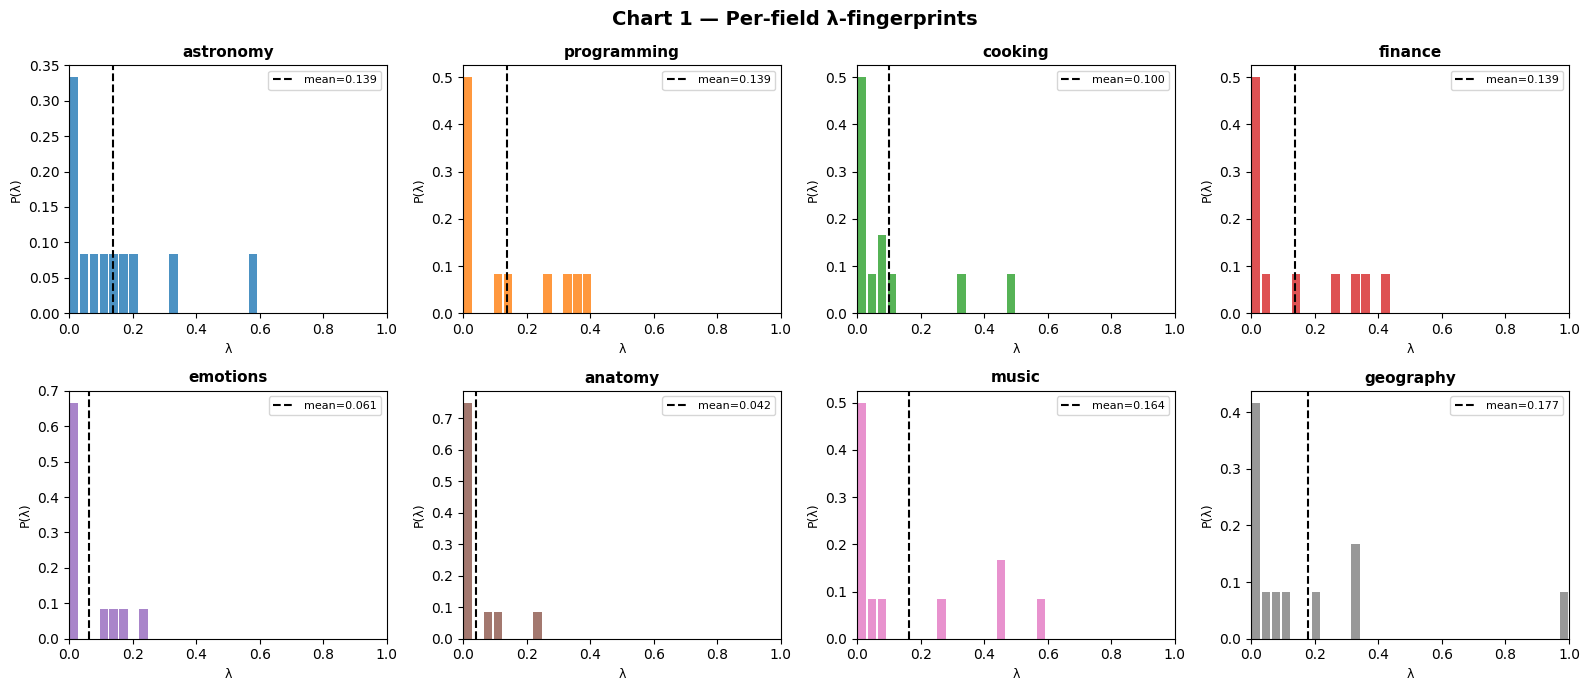

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm

COLORS8 = [cm.tab10(i) for i in range(N_FIELDS)]
FONT   = dict(family="Arial, sans-serif", size=12)

def save_fig(fig, name, dpi=160):
    fig.savefig(f"output__04/{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"  saved {name}.png")

# ── Chart 1: Fingerprint gallery ──────────────────────────────────────
bin_centres = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

fig1, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
fig1.suptitle("Chart 1 — Per-field λ-fingerprints", fontsize=14, fontweight="bold")

for ax, fname, col in zip(axes.flat, FIELD_NAMES, COLORS8):
    ax.bar(bin_centres, field_hist[fname], width=1/N_BINS*0.85, color=col, alpha=0.8)
    ax.axvline(field_stats[fname]["mean"], color="black", lw=1.5, ls="--",
               label=f"mean={field_stats[fname]['mean']:.3f}")
    ax.set_title(fname, fontsize=11, fontweight="bold")
    ax.set_xlabel("λ", fontsize=9); ax.set_ylabel("P(λ)", fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
save_fig(fig1, "c1_fingerprint_gallery")
plt.show()

  saved c2_wasserstein_matrix.png


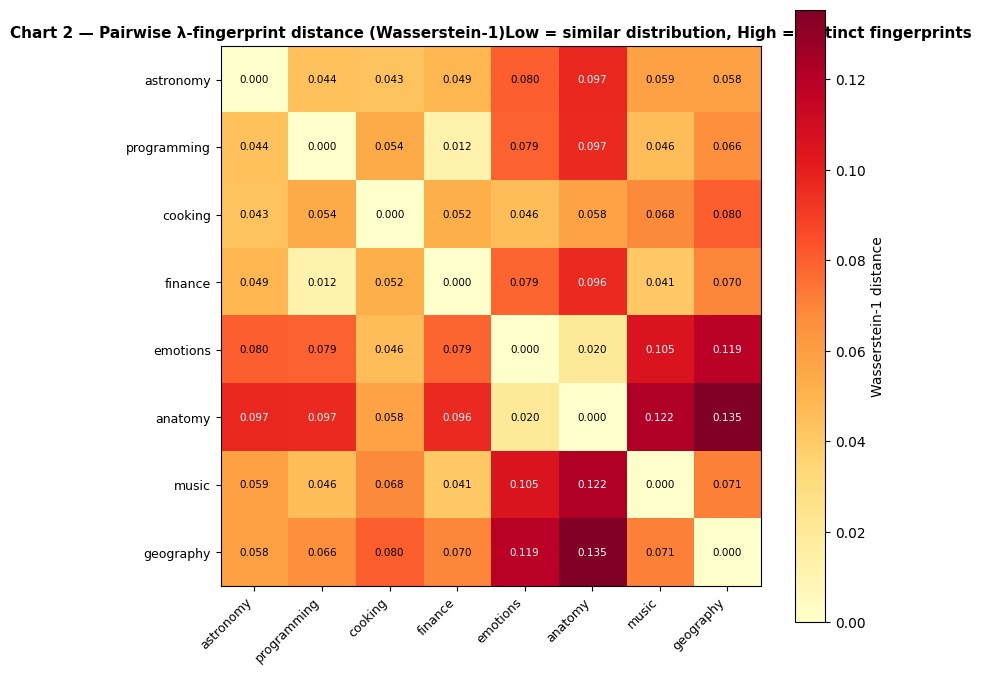

In [51]:
# ── Chart 2: Wasserstein matrix ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 7))
im = ax2.imshow(W_mat, cmap="YlOrRd", vmin=0, vmax=W_mat.max())
ax2.set_xticks(range(N_FIELDS)); ax2.set_xticklabels(FIELD_NAMES, rotation=45, ha="right", fontsize=9)
ax2.set_yticks(range(N_FIELDS)); ax2.set_yticklabels(FIELD_NAMES, fontsize=9)
for i in range(N_FIELDS):
    for j in range(N_FIELDS):
        ax2.text(j, i, f"{W_mat[i,j]:.3f}", ha="center", va="center",
                 fontsize=7.5, color="black" if W_mat[i,j] < W_mat.max()*0.6 else "white")
plt.colorbar(im, ax=ax2, label="Wasserstein-1 distance")
ax2.set_title("Chart 2 — Pairwise λ-fingerprint distance (Wasserstein-1)"
              "Low = similar distribution, High = distinct fingerprints",
              fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig(fig2, "c2_wasserstein_matrix")
plt.show()

  saved c3_rank1_accuracy.png


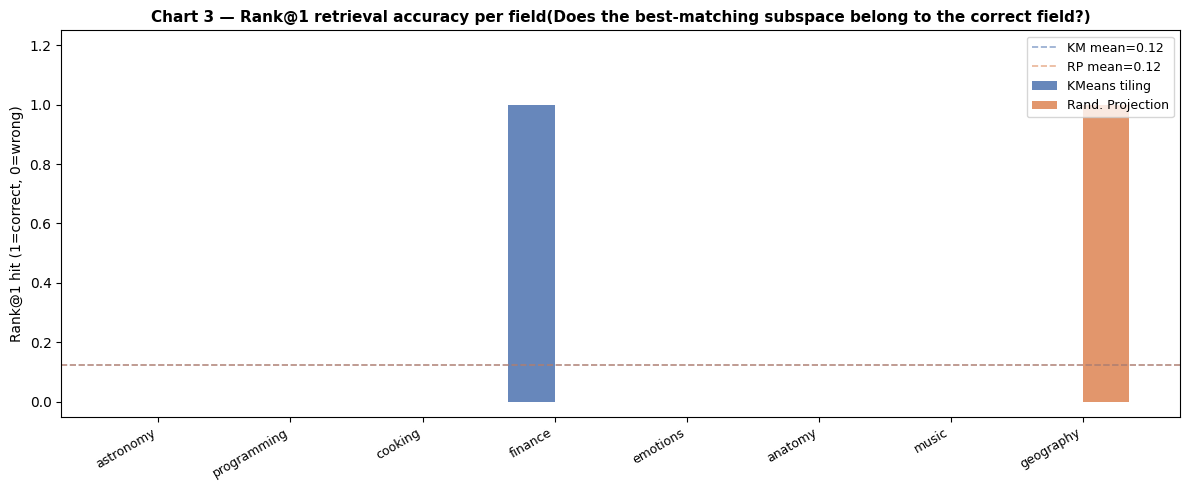

In [52]:
# ── Chart 3: Rank@1 bar chart ─────────────────────────────────────────
rank1_km_arr = [km_results[f]["rank1"] for f in FIELD_NAMES]
rank1_rp_arr = [rp_results[f]["rank1"] for f in FIELD_NAMES]
x = np.arange(N_FIELDS); w = 0.35

fig3, ax3 = plt.subplots(figsize=(12, 5))
bars1 = ax3.bar(x - w/2, rank1_km_arr, w, label="KMeans tiling", color="#4C72B0", alpha=0.85)
bars2 = ax3.bar(x + w/2, rank1_rp_arr, w, label="Rand. Projection", color="#DD8452", alpha=0.85)
ax3.axhline(rank1_acc,    color="#4C72B0", ls="--", lw=1.2, alpha=0.6, label=f"KM mean={rank1_acc:.2f}")
ax3.axhline(rank1_acc_rp, color="#DD8452", ls="--", lw=1.2, alpha=0.6, label=f"RP mean={rank1_acc_rp:.2f}")
ax3.set_xticks(x); ax3.set_xticklabels(FIELD_NAMES, rotation=30, ha="right", fontsize=9)
ax3.set_ylabel("Rank@1 hit (1=correct, 0=wrong)"); ax3.set_ylim(-0.05, 1.25)
ax3.set_title("Chart 3 — Rank@1 retrieval accuracy per field"
              "(Does the best-matching subspace belong to the correct field?)",
              fontsize=11, fontweight="bold")
ax3.legend(loc="upper right", fontsize=9)
plt.tight_layout()
save_fig(fig3, "c3_rank1_accuracy")
plt.show()

  saved c4_permutation_null.png


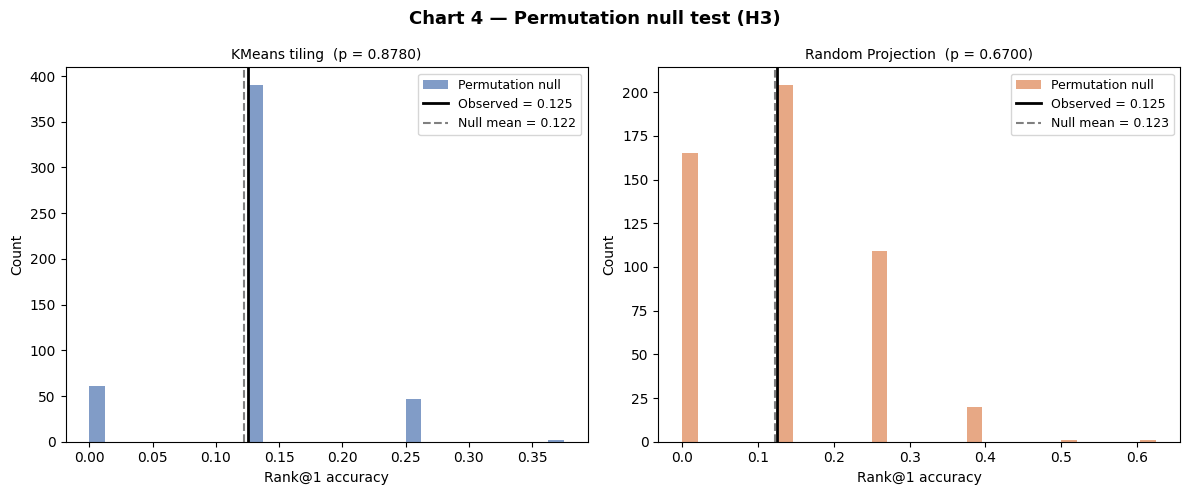

In [53]:
# ── Chart 4: Permutation null ─────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle("Chart 4 — Permutation null test (H3)", fontsize=13, fontweight="bold")

for ax, null_arr, obs, label, col in zip(
        axes4,
        [null_km, null_rp],
        [rank1_acc, rank1_acc_rp],
        ["KMeans tiling", "Random Projection"],
        ["#4C72B0", "#DD8452"]):
    ax.hist(null_arr, bins=30, color=col, alpha=0.7, label="Permutation null")
    ax.axvline(obs, color="black", lw=2.0, ls="-", label=f"Observed = {obs:.3f}")
    ax.axvline(null_arr.mean(), color="gray", lw=1.5, ls="--",
               label=f"Null mean = {null_arr.mean():.3f}")
    p_val = (null_arr >= obs).mean()
    ax.set_title(f"{label}  (p = {p_val:.4f})", fontsize=10)
    ax.set_xlabel("Rank@1 accuracy"); ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
save_fig(fig4, "c4_permutation_null")
plt.show()

  saved c5_cross_encoder.png


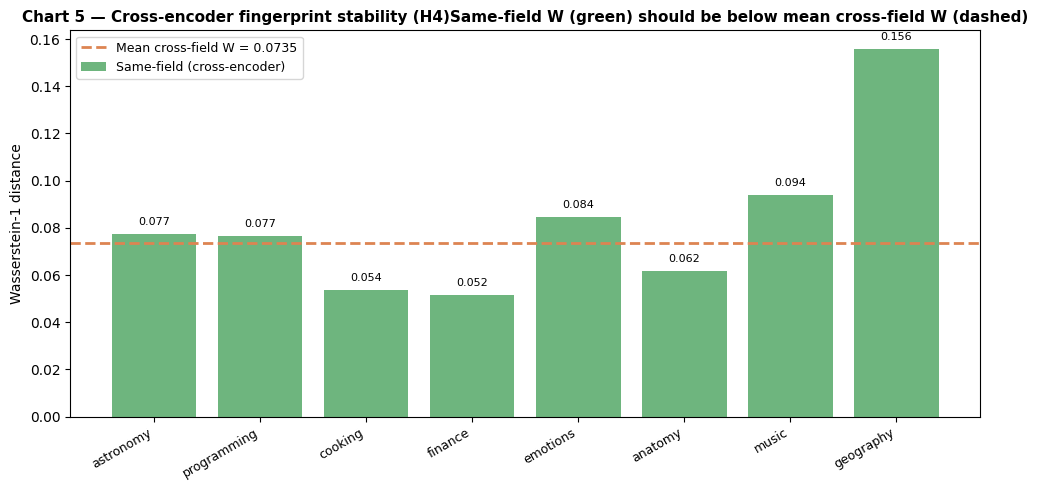

In [54]:
# ── Chart 5: Cross-encoder stability ─────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(10, 5))

x5 = np.arange(N_FIELDS)
ax5.bar(x5, same_wd, color="#55A868", alpha=0.85, label="Same-field (cross-encoder)")
ax5.axhline(cross_wd.mean(), color="#DD8452", lw=2, ls="--",
            label=f"Mean cross-field W = {cross_wd.mean():.4f}")
for xi, fname, wd in zip(x5, FIELD_NAMES, same_wd):
    ax5.text(xi, wd + 0.003, f"{wd:.3f}", ha="center", va="bottom", fontsize=8)
ax5.set_xticks(x5); ax5.set_xticklabels(FIELD_NAMES, rotation=30, ha="right", fontsize=9)
ax5.set_ylabel("Wasserstein-1 distance")
ax5.set_title("Chart 5 — Cross-encoder fingerprint stability (H4)"
              "Same-field W (green) should be below mean cross-field W (dashed)",
              fontsize=11, fontweight="bold")
ax5.legend(fontsize=9)
plt.tight_layout()
save_fig(fig5, "c5_cross_encoder")
plt.show()

## 12  Mechanistic digest

In [55]:
print("=" * 70)
print(" MECHANISTIC DIGEST — λ-Distribution Fingerprinting")
print("=" * 70)
print(f"  Model (primary):  {SOURCE}")
print(f"  Model (secondary):{SOURCE2}")
print(f"  Vocabulary:       {N_ITEMS} concepts across {N_FIELDS} fields")
print(f"  Polysemous probes:{len(POLYSEMOUS)} held-out words")
print()

print("H1 — Fingerprint distinctiveness")
print(f"  Mean off-diagonal Wasserstein: {W_mat[W_mat>0].mean():.4f}")
n_sig = (KS_pval[KS_pval > 0] < 0.05).sum()
print(f"  KS significant pairs (p<0.05): {n_sig}/{N_FIELDS*(N_FIELDS-1)}")
print(f"  → H1 {'SUPPORTED' if n_sig > N_FIELDS*(N_FIELDS-1)*0.5 else 'WEAK'}")
print()

print("H2 — Best-match subspace retrieval")
print(f"  KMeans   Rank@1={rank1_acc:.3f}   Rank@3={rank3_acc:.3f}")
print(f"  RandProj Rank@1={rank1_acc_rp:.3f}   Rank@3={rank3_acc_rp:.3f}")
h2_ok = rank1_acc > 0.3 or rank1_acc_rp > 0.3
print(f"  → H2 {'SUPPORTED' if h2_ok else 'WEAK'}")
print()

print("H3 — Above-chance fingerprint matching")
print(f"  KMeans   p={p_km:.4f}  null_mean={null_km.mean():.3f}  observed={rank1_acc:.3f}")
print(f"  RandProj p={p_rp:.4f}  null_mean={null_rp.mean():.3f}  observed={rank1_acc_rp:.3f}")
h3_ok = p_km < 0.05 or p_rp < 0.05
print(f"  → H3 {'SUPPORTED' if h3_ok else 'NOT SUPPORTED at p<0.05'}")
print()

print("H4 — Cross-encoder stability")
print(f"  Same-field W (mean):  {same_wd.mean():.4f}")
print(f"  Cross-field W (mean): {cross_wd.mean():.4f}")
print(f"  Fields where same < cross mean: {rank_stability:.3f}")
print(f"  → H4 {'SUPPORTED' if rank_stability >= 0.6 else 'WEAK — check synthetic fallback'}")
print()

print("Honest caveats")
print("  · KMeans tiling imposes hard boundaries — real subspaces may overlap.")
print("  · RP tiles depend on random seed; stability improves with more trials.")
print("  · Single-word vocabulary (n=20/field) limits fingerprint resolution.")
print("  · Synthetic fallback may inflate H4 — re-run with real encoders.")
print("  · Next step: extend to sentence-level corpora for richer fingerprints.")

 MECHANISTIC DIGEST — λ-Distribution Fingerprinting
  Model (primary):  sentence-transformers/all-MiniLM-L6-v2
  Model (secondary):sentence-transformers/all-mpnet-base-v2
  Vocabulary:       96 concepts across 8 fields
  Polysemous probes:10 held-out words

H1 — Fingerprint distinctiveness
  Mean off-diagonal Wasserstein: 0.0695
  KS significant pairs (p<0.05): 0/56
  → H1 WEAK

H2 — Best-match subspace retrieval
  KMeans   Rank@1=0.125   Rank@3=0.375
  RandProj Rank@1=0.125   Rank@3=0.125
  → H2 WEAK

H3 — Above-chance fingerprint matching
  KMeans   p=0.8780  null_mean=0.122  observed=0.125
  RandProj p=0.6700  null_mean=0.123  observed=0.125
  → H3 NOT SUPPORTED at p<0.05

H4 — Cross-encoder stability
  Same-field W (mean):  0.0819
  Cross-field W (mean): 0.0735
  Fields where same < cross mean: 0.375
  → H4 WEAK — check synthetic fallback

Honest caveats
  · KMeans tiling imposes hard boundaries — real subspaces may overlap.
  · RP tiles depend on random seed; stability improves wi

## 13  Future directions / backlog

| Notebook | Capability |
|----------|-----------|
| NB-05a | **Sentence-level fingerprinting** — replace single words with 50-sentence paragraphs per field; richer histograms, more stable fingerprints |
| NB-05b | **Soft subspace search** — replace hard KMeans cells with soft Gaussian mixture components; continuous match scores |
| NB-05c | **Multi-scale fingerprinting** — compute λ at multiple α (taumode) values; fingerprint becomes a 2-D surface over (α, λ) |
| NB-05d | **Inverse problem** — given an unlabelled subspace, retrieve its closest field label; deploy as a zero-shot field classifier |
| NB-05e | **Cross-layer tracking** — for transformer models, repeat fingerprinting per layer; track when fields crystallise |
| NB-05f | **KL divergence search** — replace Wasserstein with a KL-divergence-guided search to exploit the histogram structure directly |

---
Sources: ArrowSpace paper · `arrowspace` on PyPI · Anthropic *Mapping the Mind of a Large Language Model*  
Model: all-MiniLM-L6-v2 (primary) · all-mpnet-base-v2 (secondary)